In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns
import  tensorflow
from tensorflow import keras
from tensorflow.keras   import Sequential
from tensorflow.keras.layers  import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets  import make_circles

In [2]:
x, y = make_circles(n_samples=100, noise=0.1, random_state=1)

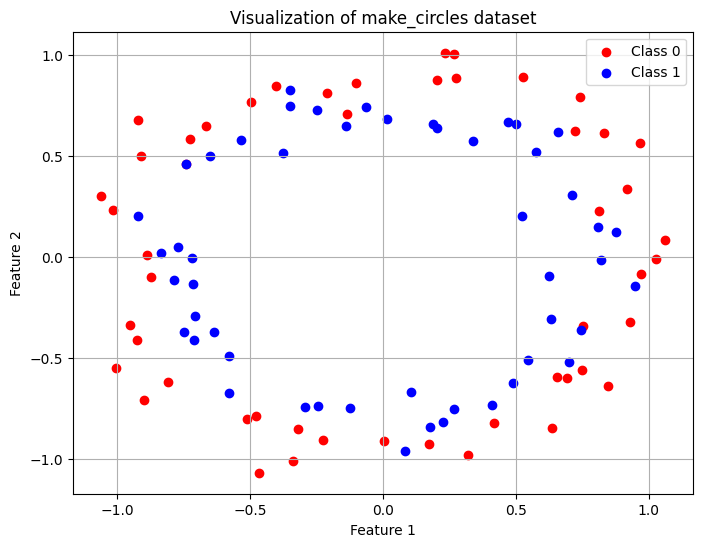

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(x[y==0, 0], x[y==0, 1], color='red', label='Class 0')
plt.scatter(x[y==1, 0], x[y==1, 1], color='blue', label='Class 1')
plt.title('Visualization of make_circles dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
model = Sequential()
model.add(Dense(64,  activation = "relu", input_dim = 2))
model.add(Dense(64,  activation = "relu"))
model.add(Dense(64,  activation = "relu"))
model.add(Dense(1,activation = "sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer = "Adam", loss = "binary_crossentropy",  metrics = ["accuracy"])

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [8]:
callback = EarlyStopping(
    monitor = "val_loss",
    min_delta = 0,
    patience  = 20,
    verbose = 1,
    mode = "auto",
    baseline = None,
    restore_best_weights = True
)

In [9]:
model.fit(x_train,  y_train, epochs = 1000,  validation_data = [x_test, y_test], callbacks = callback)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 767ms/step - accuracy: 0.5125 - loss: 0.6981 - val_accuracy: 0.5500 - val_loss: 0.6995
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5125 - loss: 0.6925 - val_accuracy: 0.3500 - val_loss: 0.7080
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5375 - loss: 0.6872 - val_accuracy: 0.3500 - val_loss: 0.7153
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5375 - loss: 0.6839 - val_accuracy: 0.3500 - val_loss: 0.7218
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5375 - loss: 0.6812 - val_accuracy: 0.3500 - val_loss: 0.7287
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5375 - loss: 0.6792 - val_accuracy: 0.3500 - val_loss: 0.7349
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5375 - loss: 0.6766 - val_accuracy: 0.3500 - val_loss: 0.7398
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5375 - loss: 0.6749 - val_accuracy: 0.3500 - 